here user will give topic ---> LLM will generate the post over it.

2.evaluate---> given the guidelines 
it will give too output
1.need improvement
2.or approve it

once evaluate llm will approve it means this will end but. if evaluate llm will generate a ffedback with need improvement meaning it will go to Optimizer llm.

optimizer again will generate post based on feedback and score received.

this will again fed back to evaluator.

this is th iterative loop it will keep running untill post gets aprove by optimizer.

In [141]:
from langgraph.graph import StateGraph , START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict , Literal ,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel , Field
from langchain_core.messages import HumanMessage ,SystemMessage
import os
import operator
load_dotenv()
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")



In [142]:
# llms
gen_llm=ChatOpenAI(model="gpt-4o-mini")
eval_llm=ChatOpenAI(model="gpt-4.1")
optimizer_llm=ChatOpenAI(model="gpt-4o-mini")

In [143]:
# structured output for evaluator
class eval_Tweet(BaseModel):
    evaluation:Literal["approved", "need_improvement"]=Field(description="this is the final evaluation result.")
    feedback:str=Field(description="Constructive feedback for the tweet,")

In [144]:
# structured model
structured_eval_llm=eval_llm.with_structured_output(eval_Tweet)

In [145]:
# state
class tweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal["approved", "need_improvement"]
    feedback:str
    iteration:int
    max_iteration:int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [146]:
# buidling function
def generateTweet(state:tweetState):
    messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day-to-day English.
""")
]
    
    response=gen_llm.invoke(messages).content
    return {"tweet":response , 'tweet_history': [response]}
    

In [147]:
def evaluateTweet(state:tweetState):
    messages=[
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic who evaluates tweets.You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality 🆕 Is this fresh, or have you seen it a hundred times before?  
2. Humor 😂 Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness ✂ Is it short, sharp, and scroll-stopping?  
4. Virality Potential 📈 Would people retweet or share it?  
5. Format 📝 Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:  
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")  
- It exceeds 280 characters  
- It reads like a traditional setup-punchline joke  
- Don’t end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterclass")  

### Respond ONLY in structured format:  
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses  
""")
]
    response=structured_eval_llm.invoke(messages)
    return {"evaluation":response.evaluation , "feedback":response.feedback,'feedback_history': [response.feedback]}


In [148]:
tweets="Indian Railways isn’t just a transport network — it’s the heartbeat of a billion journeys. 🚂 From chai vendors calling out in the early morning to the rhythmic clatter of wheels on tracks, every trip is a story. You meet strangers who feel like family, share snacks with seatmates, and witness landscapes changing from bustling cities to quiet fields. Yes, delays happen, and the middle berth still surprises you, but that’s part of the charm. It’s a moving slice of India — where life, culture, and travel blend on 60,000+ km of track. Next stop? Adventure. 🌏❤️ #IndianRailways"

In [149]:
evaluateTweet({"tweet":tweets})

{'evaluation': 'need_improvement',
 'feedback': 'This tweet fails on conciseness and format—it’s far too long for Twitter’s 280-character limit and reads like a sentimental magazine paragraph, not a tweet. While the descriptive storytelling is evocative and may tug at the nostalgic heartstrings of Indian Railways fans, it completely lacks humor and punchiness. There’s nothing here to surprise, amuse, or make people stop scrolling; the phrasing has been seen many times before in travel or Indian cultural commentary. Virality potential is low without a catchy or witty angle. To improve: focus the message into one vivid, punchy observation or clever take, and stay within character limits.',
 'feedback_history': ['This tweet fails on conciseness and format—it’s far too long for Twitter’s 280-character limit and reads like a sentimental magazine paragraph, not a tweet. While the descriptive storytelling is evocative and may tug at the nostalgic heartstrings of Indian Railways fans, it compl

In [150]:
def  optimizeTweet(state:tweetState):
    messages=[
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")

    ]
    response=optimizer_llm.invoke(messages).content
    iteration=state['iteration']+1

    return {"tweet":response, "iteration":iteration}
    

In [151]:
def route_evaluation(state:tweetState):
    if state['evaluation']=="approved" or state['iteration']>=state['max_iteration']:
        return "approved"
    
    else:
        return "need_improvement"

In [152]:
graph=StateGraph(tweetState)

graph.add_node("generateTweet",generateTweet)
graph.add_node("evaluateTweet",evaluateTweet)
graph.add_node("optimizeTweet",optimizeTweet)

graph.add_edge(START,"generateTweet")
graph.add_edge("generateTweet","evaluateTweet")

# here we will see iteration

graph.add_conditional_edges("evaluateTweet",route_evaluation,{'approved':END ,'need_improvement':'optimizeTweet' })

graph.add_edge("optimizeTweet","evaluateTweet")

In [153]:
workflow=graph.compile()

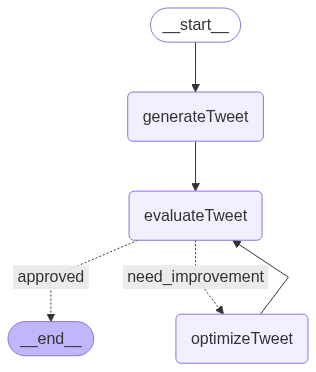

In [154]:
workflow

In [159]:
initial_state={
    "topic":"The Hindu",
    "iteration":1,
    "max_iteration":5
}

final_state=workflow.invoke(initial_state)


In [160]:
final_state

{'topic': 'The Hindu',
 'tweet': 'The Hindu: your one-stop shop for world news, gourmet recipes, and juicy cat gossip—all while you debate yoga vs. napping. It’s basically the Swiss Army knife of newspapers. Because who doesn’t want a side of existential crisis with their headlines? 📰✨',
 'evaluation': 'approved',
 'feedback': 'This tweet demonstrates strong originality by presenting The Hindu as a humorous, multi-purpose newspaper, likening it to a Swiss Army knife. There’s a playful, irreverent tone throughout, with lines about gourmet recipes and juicy cat gossip injecting solid absurdist humor. The yoga vs. napping debate is a novel touch for Indian cultural context, adding a layer of relatability. While the closing existential crisis joke could risk being slightly overused, here it still fits with the satirical vibe. The tweet is well-structured, remains under 280 characters, and avoids forbidden formats. Overall, its fresh, clever angle and tight delivery boost its scroll-stoppin